### **1. Data Extraction & Cleaning**

In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

In [2]:
customer_churn = pd.read_csv('Customer-Churn-Records.csv')

In [3]:
customer_churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
# Delete row
df = customer_churn.drop(columns=['Surname', 'RowNumber','CustomerId'])

The variables RowNumber, CustomerId, and Surname were removed during the data cleaning process because they represent identifiers rather than meaningful customer attributes.
Additionally, removing personal identifiers helps to protect customers' privacy

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [6]:
# Customer churn %
df['Exited'].value_counts(normalize=True)

,proportion
Exited,
0,0.7962
1,0.2038


In [7]:
df[['Exited','Complain']].value_counts()

,,count
Exited,Complain,
0,0,7952
1,1,2034
0,1,10
1,0,4


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Complain            10000 non-null  int64  
 12  Satisfaction Score  10000 non-null  int64  
 13  Card Type           10000 non-null  object 
 14  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 1.1+

In [9]:
df = df.convert_dtypes()

In [10]:
df.shape

(10000, 15)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  Int64  
 1   Geography           10000 non-null  string 
 2   Gender              10000 non-null  string 
 3   Age                 10000 non-null  Int64  
 4   Tenure              10000 non-null  Int64  
 5   Balance             10000 non-null  Float64
 6   NumOfProducts       10000 non-null  Int64  
 7   HasCrCard           10000 non-null  Int64  
 8   IsActiveMember      10000 non-null  Int64  
 9   EstimatedSalary     10000 non-null  Float64
 10  Exited              10000 non-null  Int64  
 11  Complain            10000 non-null  Int64  
 12  Satisfaction Score  10000 non-null  Int64  
 13  Card Type           10000 non-null  string 
 14  Point Earned        10000 non-null  Int64  
dtypes: Float64(2), Int64(10), string(3)
memory usage: 1.3 

In [12]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,650.5288,38.9218,5.0128,76485.889288,1.5302,0.7055,0.5151,100090.239881,0.2038,0.2044,3.0138,606.5151
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,350.0,18.0,0.0,0.0,1.0,0.0,0.0,11.58,0.0,0.0,1.0,119.0
25%,584.0,32.0,3.0,0.0,1.0,0.0,0.0,51002.11,0.0,0.0,2.0,410.0
50%,652.0,37.0,5.0,97198.54,1.0,1.0,1.0,100193.915,0.0,0.0,3.0,605.0
75%,718.0,44.0,7.0,127644.24,2.0,1.0,1.0,149388.2475,0.0,0.0,4.0,801.0
max,850.0,92.0,10.0,250898.09,4.0,1.0,1.0,199992.48,1.0,1.0,5.0,1000.0


In [13]:
df['Gender'] = df['Gender'].astype('category')
df['Card Type'] = df['Card Type'].astype('category')

### **2. Correlation Heatmap**

In [14]:
# Numeric column filter
df_num = df.select_dtypes(include='number')
# Remove leakage variable
df_num = df_num.drop(columns=['Complain'])
# Heatmap
df_num.corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.026771,-0.012599,0.000077
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285296,-0.000876,0.002222
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.013656,0.008663,-0.010196
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118577,-0.002588,0.014608
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047611,-0.011394,-0.015330
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.006976,-0.000212,-0.011041
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156356,0.010236,-0.004983
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012490,-0.013747,-0.001515
Exited,-0.026771,0.285296,-0.013656,0.118577,-0.047611,-0.006976,-0.156356,0.012490,1.000000,-0.005849,-0.004628
Satisfaction Score,-0.012599,-0.000876,0.008663,-0.002588,-0.011394,-0.000212,0.010236,-0.013747,-0.005849,1.000000,-0.014400


##### The variable “Complain” was excluded from modeling due to its near-perfect correlation with the target variable (Exited), indicating potential data leakage.


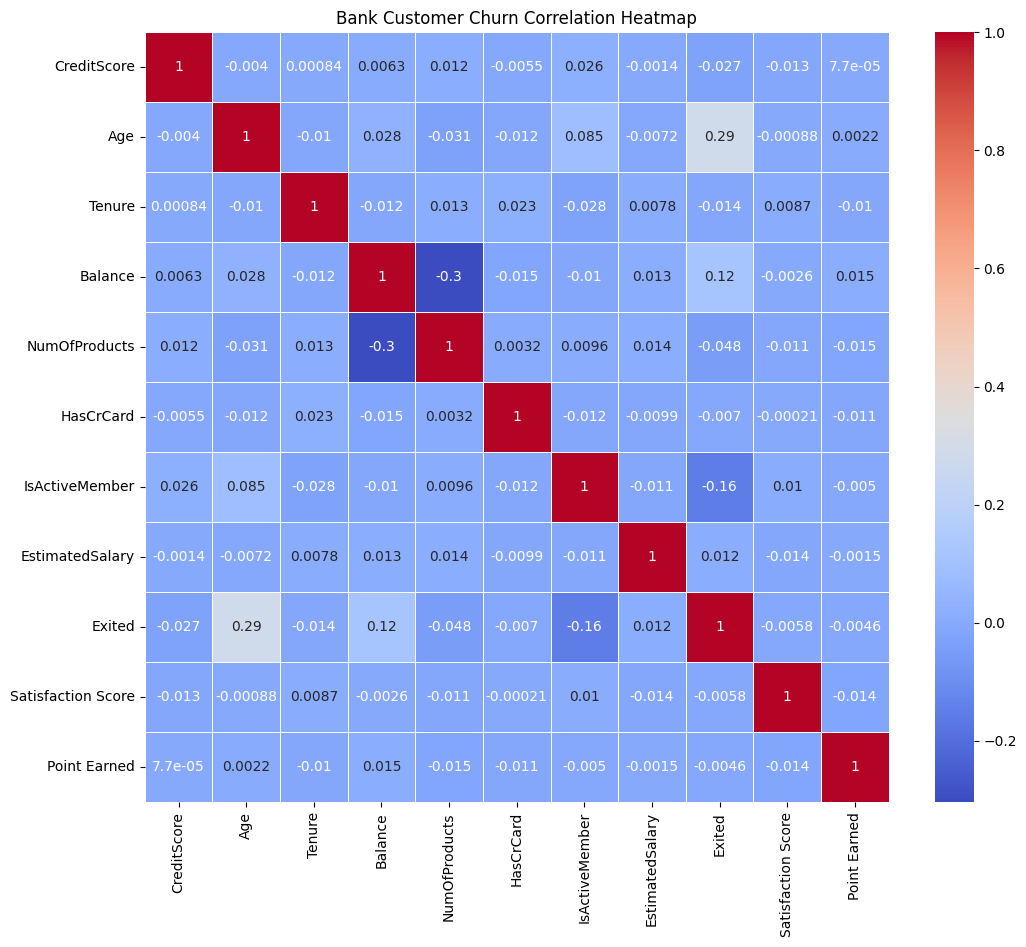

In [15]:
plt.figure(figsize=(12,10))
plt.title('Bank Customer Churn Correlation Heatmap')
sns.heatmap(df_num.corr(), annot=True, linewidth=.5, cmap='coolwarm')
plt.show()

Based on the correlation heatmap, Age shows a weak positive correlation with customer churn (0.29), indicating that older customers are more likely to leave the bank. A similar pattern is observed for Balance, where customers with higher account balances tend to have a higher probability of churn.

In addition, IsActiveMember has a negative correlation with churn (-0.16), meaning that active customers are less likely to leave the bank. This highlights the importance of customer engagement in improving retention.

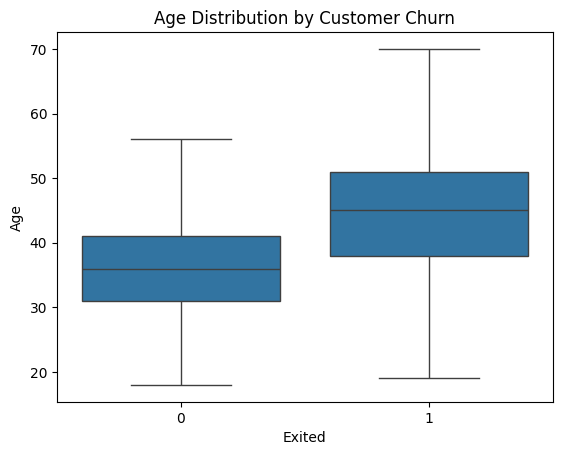

In [16]:
# Boxplot
sns.boxplot(x='Exited', y='Age', data=df, showfliers=False)

plt.title("Age Distribution by Customer Churn")
plt.show()

In addition to correlation heatmap, the boxplot also shows that customers with older age tend to churn compared to customers who choose to remain with the bank. As the median age of churned customers is noticebly higher (45 vs 35) further emphasizes that age maybe an important factor influencing churn.

### **3. Logistic Regression Model**

In [17]:
# Building logistic regression model as the target variable is (exited) is binary (0 or 1),
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.0,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.8,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.0,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.1,0,0,5,GOLD,425


Based on correlation heatmap, three variables showing the strongest relationship with customer churn were selected for the logistic regression model: Age, Balance, IsActiveMember.

Variables with very weak correlations were excluded to simplify the model and improve interpretability.

In [18]:
y = df['Exited']
X = df[['Age', 'Balance', 'IsActiveMember']]
X = sm.add_constant(X)
X = X.astype(float)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.441020
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.1278
Time:                        20:27:30   Log-Likelihood:                -4410.2
converged:                       True   LL-Null:                       -5056.3
Covariance Type:            nonrobust   LLR p-value:                7.620e-280
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -4.2654      0.115    -37.000      0.000      -4.491      -4.039
Age              

The logistic regression model is statistically significant (LLR p-value < 0.05), indicating that the selected variables are useful to explaining customer churn behavior.

The model achieved a Pseudo R² of 0.1278, indicating that approximately 12.8% of the variation in customer churn can be explained by the selected variables. While this value is relatively modest, it is common in behavioral and customer analytics models where churn is influenced by many external factors not captured in the dataset.

### **4. Model Evaluation (Train/Test)**


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) #random_state=42 fixed random record to test
X = X.astype(float)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model_eva = sm.Logit(y_train, X_train).fit()
print(model_eva.summary())

Optimization terminated successfully.
         Current function value: 0.446703
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6996
Method:                           MLE   Df Model:                            3
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.1257
Time:                        20:28:13   Log-Likelihood:                -3126.9
converged:                       True   LL-Null:                       -3576.4
Covariance Type:            nonrobust   LLR p-value:                1.509e-194
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -4.1992      0.136    -30.834      0.000      -4.466      -3.932
Age              

In [25]:
y_pred_prob = model_eva.predict(X_test)
y_pred_prob.sample(5)

,0
7501,0.347018
330,0.159018
9655,0.258856
1623,0.186906
736,0.575217


In [43]:
threshold = 0.3
predicted_classes = np.where(y_pred_prob > threshold, 1, 0)
pd.DataFrame(predicted_classes)

,0
0,0
1,0
2,0
3,1
4,0
...,...
2995,0
2996,0
2997,0
2998,0


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

accuracy = np.mean(predicted_classes == y_test)
precision = precision_score(y_test, predicted_classes)
recall = recall_score(y_test, predicted_classes)
f1 = f1_score(y_test, predicted_classes)

print('Accuracy:', accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.779
Precision: 0.4393241167434716
Recall: 0.4897260273972603
F1-score: 0.4631578947368421


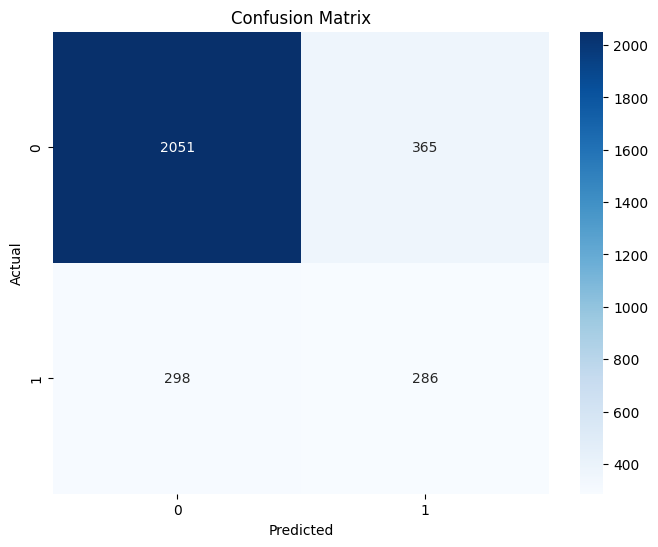

In [28]:
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### **5. Recommendations for Marketing Team** ⭐

Based on these findings, the marketing team should focus on developing **targeted retention strategies** for older customers, as this segment shows a higher likelihood of churn.

Additionally, the bank may consider creating **specialised financial incentives** or **personalized offers** for customers with high balances to ease their stress and reduce the risk of churning.

Finally, strengthening existing customer base via engagement programs such as **loyalty rewards** or advertise **exclusive member benefits** can encourage inactive customers to become active members, thereby reducing overall churn rates.


In [29]:
y_test #actual lable (hide)

,Exited
6252,0
4684,0
1731,0
4742,0
4521,0
...,...
8014,0
1074,0
3063,0
6487,0


In [30]:
pd.DataFrame(predicted_classes) # predict label

,0
0,0
1,0
2,0
3,1
4,0
...,...
2995,0
2996,0
2997,0
2998,0
